In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import preprocess_input

In [2]:
train_data= ("../data/chest_xray/train")
test_data=("../data/chest_xray/test")
val_data=("../data/chest_xray/val")

In [3]:
train_datagen= ImageDataGenerator(
    preprocessing_function= preprocess_input, 
    
    rotation_range= 20, 
    zoom_range=0.2, 
    width_shift_range=0.1, 
    height_shift_range=0.1,
    horizontal_flip=True
    )

test_datagen= ImageDataGenerator(
    preprocessing_function= preprocess_input
)

In [4]:
train_image= train_datagen.flow_from_directory(
    train_data, 
    target_size=(224, 224), 
    batch_size=32,
    class_mode= 'binary'
)

test_image= test_datagen.flow_from_directory(
    test_data, 
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_image= test_datagen.flow_from_directory(
    val_data,
    target_size=(224, 224),
    batch_size=32, 
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [5]:
print(train_image.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1172218..2.519276].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6143272].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5634527].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6217828].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.7344625].


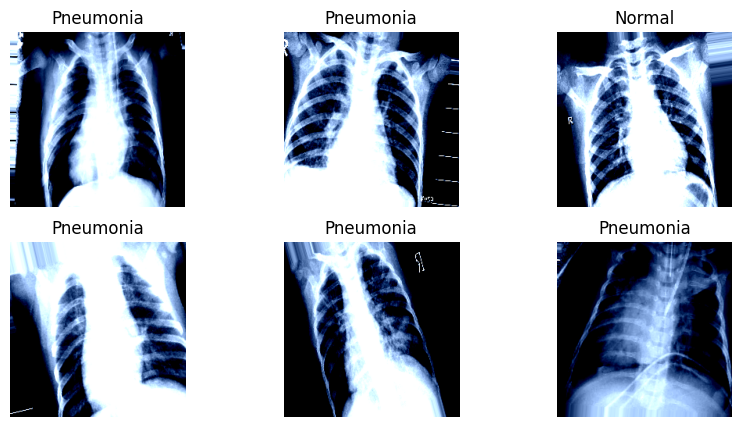

In [6]:
images, labels= next(train_image)

plt.figure(figsize=(10, 5))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i] ==1 else "Normal")
    plt.axis("off")
    
plt.show()

In [7]:
base_model=DenseNet121(
    weights='imagenet',
    include_top= False,
    input_shape=(224,224,3)
)

In [8]:
for layers in base_model.layers:
    layers.trainable=False

In [9]:
from tensorflow.keras.layers import (
    Dense,
    Dropout
    )

In [10]:
x= base_model.output
x= GlobalAveragePooling2D()(x)
x= Dense(128, activation='relu')(x)
x= Dropout(0.5)(x)

predictions=Dense(1, activation ='sigmoid')(x)

In [11]:
model=Model(
    inputs=base_model.input, 
    outputs=predictions
)

In [12]:
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
early_stop= EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
    )

In [18]:
history=model.fit(
    train_image, 
    validation_data= val_image,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 626ms/step - accuracy: 0.8811 - loss: 0.2906 - val_accuracy: 0.8750 - val_loss: 0.2689
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 624ms/step - accuracy: 0.9321 - loss: 0.1726 - val_accuracy: 0.9375 - val_loss: 0.1974
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 622ms/step - accuracy: 0.9354 - loss: 0.1613 - val_accuracy: 0.9375 - val_loss: 0.2042
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 611ms/step - accuracy: 0.9440 - loss: 0.1447 - val_accuracy: 0.8750 - val_loss: 0.1861
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 607ms/step - accuracy: 0.9490 - loss: 0.1339 - val_accuracy: 0.9375 - val_loss: 0.1670
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 613ms/step - accuracy: 0.9525 - loss: 0.1264 - val_accuracy: 0.9375 - val_loss: 0.1749
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 616ms/step - accuracy: 0.9517 - loss: 0.1308 - val_accuracy: 0.8750 - val_loss: 0.2250


In [19]:
test_loss, test_accuracy= model.evaluate(test_image)
print("Test Loss", test_loss)
print('Test Accuracy', test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 598ms/step - accuracy: 0.8830 - loss: 0.2712
Test Loss 0.271226167678833
Test Accuracy 0.8830128312110901


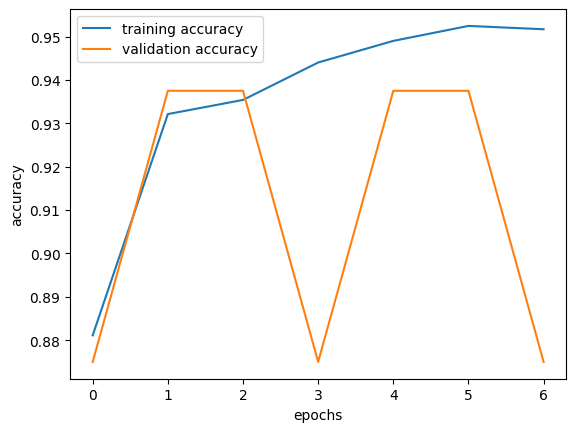

In [21]:
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

plt.show()

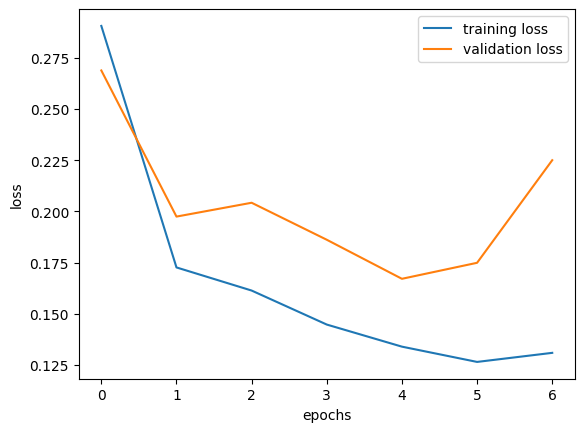

In [23]:
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label= 'validation loss')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

plt.show()

In [24]:
test_image.reset()

In [27]:
predictons_image=model.predict(test_image)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 608ms/step


In [29]:
predicted_classes=(predictons_image > 0.5).astype('int32')

In [30]:
true_classes=test_image.classes

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

In [33]:
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.41      0.36      0.39       234
           1       0.64      0.69      0.66       390

    accuracy                           0.57       624
   macro avg       0.53      0.53      0.52       624
weighted avg       0.56      0.57      0.56       624

